In [70]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import chess
import chess.svg
import json
import math
import cv2
from pathlib import Path
from IPython.display import display

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 512
RESULTS_DIR = Path("experiments/results")
MODEL_DIR = Path("models")

In [71]:
# ==========================================
# Configuration
# ==========================================
class Config:
    # 'CNN' / 'MLP' / TRANSFORMER'
    ACTIVE_MODEL = "CNN" 
    
    # 'FEN' / 'DATASET'
    TEST_MODE = "DATASET" 

    # --- Change if TEST_MODE = "FEN" ---
    FEN_STRING = "5kq1/2p5/pp1pp2p/2P2pp1/PP1PP2P/5PP1/8/1K6 b - - 0 1"
    TRUE_LABEL_FOR_FEN = 2 # Manually set the expected class (0-6) for this FEN
    
    # --- Change if TEST_MODE = "DATASET" ---
    ERROR_MAGNITUDE = "0" 
    IDX_IN_LIST = 1 

MODEL_REGISTRY = {
    "CNN": {
        "name": "seresnet_new_v2_16",
        "dataset_dir": Path("./dataset_planes_cp/"),
        "is_3d": True,
        "index_file": "seresnet_new_v2_16_all_indices.json"
    },
    "MLP": {
        "name": "probs_mlp_v4",
        "dataset_dir": Path("./dataset_bitmaps_cp/"),
        "is_3d": False,
        "index_file": "run_2026_01_22_probs_mlp_v4_all_indices.json"
    },
    "TRANSFORMER": {
        "name": "transformer_v1",
        "dataset_dir": Path("./dataset_planes_cp/"),
        "is_3d": True,
        "index_file": "transformer_v1_all_indices.json"
    },
    "CNN_PROBE": {
        "name": "seresnet_new_v2_16_probe",
        "dataset_dir": Path("./dataset_planes_cp/"),
        "is_3d": True,
        "index_file": "seresnet_new_v1_16_probe_failure_indices.json"
    },
    "MLP_PROBE": {
        "name": "probs_mlp_v4_probe",
        "dataset_dir": Path("./dataset_bitmaps_cp/"),
        "is_3d": False,
        "index_file": "probs_mlp_v4_probe_failure_indices.json"
    },
    "TRANSFORMER_PROBE": {
        "name": "transformer_v1_probe",
        "dataset_dir": Path("./dataset_planes_cp/"),
        "is_3d": True,
        "index_file": "transformer_v1_probe_failure_indices.json"
    }
}

ACTIVE_SETUP = MODEL_REGISTRY[Config.ACTIVE_MODEL]

In [72]:
# ==========================================
# Utility Functions
# ==========================================
def tensor_to_fen(tensor):
    index_to_piece = {0:'P', 1:'N', 2:'B', 3:'R', 4:'Q', 5:'K', 
                      6:'p', 7:'n', 8:'b', 9:'r', 10:'q', 11:'k'}
    board = chess.Board(None)
    for piece_idx in range(12):
        for row in range(8):
            for col in range(8):
                if tensor[piece_idx, row, col] == 1:
                    board.set_piece_at(chess.square(col, row), chess.Piece.from_symbol(index_to_piece[piece_idx]))

    board.turn = chess.WHITE if tensor[12, 0, 0] == 1 else chess.BLACK
    castling_fen = ""
    if tensor[13, 0, 0] == 1: castling_fen += "K"
    if tensor[14, 0, 0] == 1: castling_fen += "Q"
    if tensor[15, 0, 0] == 1: castling_fen += "k"
    if tensor[16, 0, 0] == 1: castling_fen += "q"
    board.set_castling_fen(castling_fen if castling_fen else "-")

    ep_rows, ep_cols = np.where(tensor[18] == 1)
    if len(ep_rows) > 0:
        board.ep_square = chess.square(ep_cols[0], ep_rows[0])
    return board.fen()

def fen_to_tensor(fen):
    board = chess.Board(fen)
    tensor = np.zeros((19, 8, 8), dtype=np.float32)
    piece_to_channel = {"P":0, "N":1, "B":2, "R":3, "Q":4, "K":5, "p":6, "n":7, "b":8, "r":9, "q":10, "k":11}
    for square, piece in board.piece_map().items():
        row, col = divmod(square, 8)
        tensor[piece_to_channel[piece.symbol()], row, col] = 1
    
    if board.turn == chess.WHITE: tensor[12, :, :] = 1
    if board.has_kingside_castling_rights(chess.WHITE): tensor[13, :, :] = 1
    if board.has_queenside_castling_rights(chess.WHITE): tensor[14, :, :] = 1
    if board.has_kingside_castling_rights(chess.BLACK): tensor[15, :, :] = 1
    if board.has_queenside_castling_rights(chess.BLACK): tensor[16, :, :] = 1
    if board.is_check(): tensor[17, :, :] = 1
    if board.ep_square is not None:
        row, col = divmod(board.ep_square, 8)
        tensor[18, row, col] = 1
    return tensor

def vector_to_fen(vector):
    index_to_piece = {0:'P', 1:'N', 2:'B', 3:'R', 4:'Q', 5:'K', 6:'p', 7:'n', 8:'b', 9:'r', 10:'q', 11:'k'}
    board = chess.Board(None) 
    for piece_idx in range(12):
        for square in range(64):
            if vector[piece_idx * 64 + square] == 1:
                board.set_piece_at(square, chess.Piece.from_symbol(index_to_piece[piece_idx]))
                
    board.turn = chess.WHITE if vector[768] == 1 else chess.BLACK
    castling_fen = ""
    if vector[769] == 1: castling_fen += "K"
    if vector[770] == 1: castling_fen += "Q"
    if vector[771] == 1: castling_fen += "k"
    if vector[772] == 1: castling_fen += "q"
    board.set_castling_fen(castling_fen if castling_fen else "-")
    return board.fen()

def fen_to_vector(fen):
    board = chess.Board(fen)
    vector = np.zeros(775, dtype=np.float32)
    piece_to_idx = {"P":0, "N":1, "B":2, "R":3, "Q":4, "K":5, "p":6, "n":7, "b":8, "r":9, "q":10, "k":11}
    for square, piece in board.piece_map().items():
        vector[piece_to_idx[piece.symbol()] * 64 + square] = 1
        
    if board.turn == chess.WHITE: vector[768] = 1
    if board.has_kingside_castling_rights(chess.WHITE): vector[769] = 1
    if board.has_queenside_castling_rights(chess.WHITE): vector[770] = 1
    if board.has_kingside_castling_rights(chess.BLACK): vector[771] = 1
    if board.has_queenside_castling_rights(chess.BLACK): vector[772] = 1
    return vector

def get_piece_gradients(model, input_tensor, target_class):
    model.eval()
    input_tensor.requires_grad = True
    pred = model(input_tensor)
    score = pred[0, target_class]
    score.backward()
    return input_tensor.grad.data.cpu().numpy()[0]

def plot_chess_gradients(gradients):
    fig, ax1 = plt.subplots(figsize=(15, 6))
    ax1.plot(gradients, color="b", linewidth=1, label='Gradient Magnitude')
    channels = ['P', 'N', 'B', 'R', 'Q', 'K', 'p', 'n', 'b', 'r', 'q', 'k']
    
    y_min, y_max = np.min(gradients), np.max(gradients)
    y_range = y_max - y_min
    text_y_pos = y_max + (y_range * 0.05) 
    
    for i, channel in enumerate(channels):
        start_idx, end_idx = i * 64, (i + 1) * 64
        if i % 2 == 0:
            ax1.axvspan(start_idx, end_idx, color='gray', alpha=0.1, lw=0)
        ax1.axvline(x=end_idx, color='gray', linestyle=':', alpha=0.5)
        ax1.text(start_idx + 32, text_y_pos, channel, ha='center', va='bottom', fontsize=12, fontweight='bold', color='#333333')

    ax1.set_title('Gradient Sensitivity by Feature Index', fontsize=14, pad=25)
    ax1.set_xlim(0, 767)
    ax1.set_ylim(y_min, y_max + (y_range * 0.15))
    ax1.grid(True, axis='y', alpha=0.3, linestyle='--')
    sns.despine()
    plt.tight_layout()
    plt.show()

def plot_chess_heatmap(gradients, fen_str, true_label, pred_label):
    piece_grads = gradients[:768].reshape(12, 64)
    saliency = np.sum(np.abs(piece_grads), axis=0)
    heatmap = np.flipud(saliency.reshape(8, 8))

    fig, ax = plt.subplots(figsize=(6, 6))
    sns.heatmap(heatmap, cmap="viridis", alpha=0.7, zorder=2, ax=ax, cbar=False)
    ax.set_title(f"Saliency Map (True: {true_label}, Pred: {pred_label})")
    plt.show()
    print("Actual Board Position:")
    display(chess.svg.board(chess.Board(fen_str), size=350))

In [73]:
# ==========================================
# Dataset & Models
# ==========================================
class ChessDataset(Dataset):
    def __init__(self, root_dir: Path, split: str):
        self.X = np.load(root_dir / f"{split}_X.npy", mmap_mode='r')
        self.y = np.load(root_dir / f"{split}_y.npy", mmap_mode='r')

    def __len__(self): return self.X.shape[0]
    
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)

# --- MLP ---
class MLP(nn.Module):
    def __init__(self, input_shape=775, output_shape=7):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_shape, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, output_shape)
        )
    def forward(self, x): return self.network(x)

# --- CNN ---
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction), nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels), nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.mlp(self.avg_pool(x).view(b, c)).view(b, c, 1, 1)
        return x * y.expand_as(x)

class DropPath(nn.Module):
    def __init__(self, drop_prob: float = 0.):
        super().__init__()
        self.drop_prob = drop_prob
    def forward(self, x):
        if self.drop_prob == 0. or not self.training: return x
        keep_prob = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = x.new_empty(shape).bernoulli_(keep_prob)
        return x.div(keep_prob) * random_tensor

class ResidualBlock(nn.Module):
    def __init__(self, channels, drop_prob=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1, self.bn2 = nn.BatchNorm2d(channels), nn.BatchNorm2d(channels)
        self.relu, self.se = nn.ReLU(), SEBlock(channels, reduction=8)
        self.drop_path = DropPath(drop_prob) if drop_prob > 0. else nn.Identity()
    def forward(self, x):
        identity = x 
        x = self.se(self.bn2(self.conv2(self.relu(self.bn1(self.conv1(x))))))
        return self.relu(self.drop_path(x) + identity)

class SEResNet(nn.Module):
    def __init__(self, in_channels=19, channels=64, num_blocks=16, num_classes=7, drop_path_rate=0.0):
        super().__init__()
        self.initialconv = nn.Sequential(
            nn.Conv2d(in_channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels), nn.ReLU()
        )
        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, num_blocks)]
        self.res_tower = nn.Sequential(*[ResidualBlock(channels, drop_prob=dpr[i]) for i in range(num_blocks)])
        self.bottleneck = nn.Sequential(
            nn.Conv2d(channels, 32, kernel_size=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU()
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.Linear(32, 256), nn.ReLU(), nn.Dropout(0.5), nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.bottleneck(self.res_tower(self.initialconv(x))))

# --- TRANSFORMER ---
class Ffn(nn.Module):
    def __init__(self, embed_dim, ffn_dim):
        super().__init__()
        self.linear1 = nn.Linear(embed_dim, ffn_dim)
        self.activation = nn.ReLU() 
        self.linear2 = nn.Linear(ffn_dim, embed_dim)
    def forward(self, x):
        return self.linear2(self.activation(self.linear1(x)))

class EncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ffn_dim, num_blocks):
        super().__init__()
        self.alpha = math.pow(2.0 * num_blocks, -0.25)
        self.mha = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.ln1, self.ln2 = nn.LayerNorm(embed_dim), nn.LayerNorm(embed_dim)
        self.ffn = Ffn(embed_dim, ffn_dim)
    def forward(self, x):
        attn_out, _ = self.mha(x, x, x, need_weights=False)
        x = x + attn_out * self.alpha
        identity = self.ln1(x)
        x = identity + self.ffn(identity) * self.alpha
        return self.ln2(x)

class Transformer(nn.Module):
    def __init__(self, input_channels=19, embed_dim=128, num_heads=4, ffn_dim=512, num_blocks=6, num_classes=7):
        super().__init__()
        self.embedding = nn.Linear(input_channels, embed_dim)
        self.embed_activation = nn.ReLU()
        self.embed_norm = nn.LayerNorm(embed_dim)
        self.pos_embedding = nn.Parameter(torch.randn(1, 64, embed_dim))
        nn.init.normal_(self.pos_embedding, mean=0, std=0.02)
        
        self.blocks = nn.ModuleList([EncoderBlock(embed_dim, num_heads, ffn_dim, num_blocks) for _ in range(num_blocks)])
        self.classifier_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2), nn.ReLU(), nn.Linear(embed_dim // 2, num_classes)
        )
    def forward(self, x):
        x = x.permute(0, 2, 3, 1).flatten(1, 2)
        x = self.embed_norm(self.embed_activation(self.embedding(x))) + self.pos_embedding
        for block in self.blocks: x = block(x)
        return self.classifier_head(x.mean(dim=1))

In [74]:
# ==========================================
# Load Models
# ==========================================
if Config.ACTIVE_MODEL == "CNN":
    model = SEResNet(in_channels=19, channels=64, num_blocks=16, num_classes=7, drop_path_rate=0.0).to(DEVICE)
elif Config.ACTIVE_MODEL == "MLP":
    model = MLP(775, 7).to(DEVICE)
elif Config.ACTIVE_MODEL == "TRANSFORMER":
    model = Transformer(input_channels=19, embed_dim=128, num_heads=4, ffn_dim=512, num_blocks=6, num_classes=7).to(DEVICE)

model_path = MODEL_DIR / f"{ACTIVE_SETUP['name']}.pth"
try:
    model.load_state_dict(torch.load(model_path))
    print(f"Loaded weights for {Config.ACTIVE_MODEL} from {model_path}")
except FileNotFoundError:
    print(f"Weight file not found at {model_path}. Please check your directories.")

model.eval()

Loaded weights for CNN from models\seresnet_new_v2_16.pth


SEResNet(
  (initialconv): Sequential(
    (0): Conv2d(19, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (res_tower): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
      (se): SEBlock(
        (avg_pool): AdaptiveAvgPool2d(output_size=1)
        (mlp): Sequential(
          (0): Linear(in_features=64, out_features=8, bias=True)
          (1): ReLU(inplace=True)
          (2): Linear(in_features=8, out_features=64, bias=True)
          (3): Sigmoid()
        )
      )
      (drop_p


Mode: DATASET | Analyzing Test Sample Index: 2
FEN: 1r5k/p1r3qp/1p1QRn2/5p2/2PB1P2/7P/P1PN2P1/6K1 w - - 0 1
True Label: 0 | Predicted: 0
Error Magnitude: 0


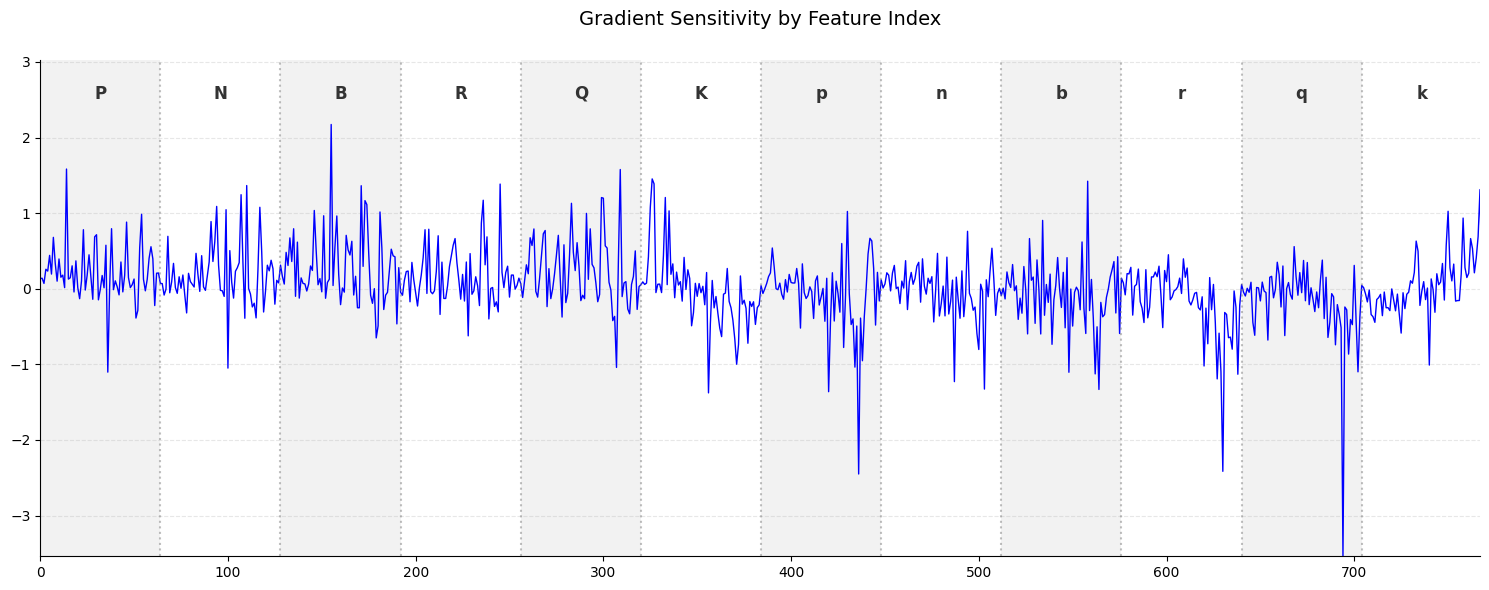

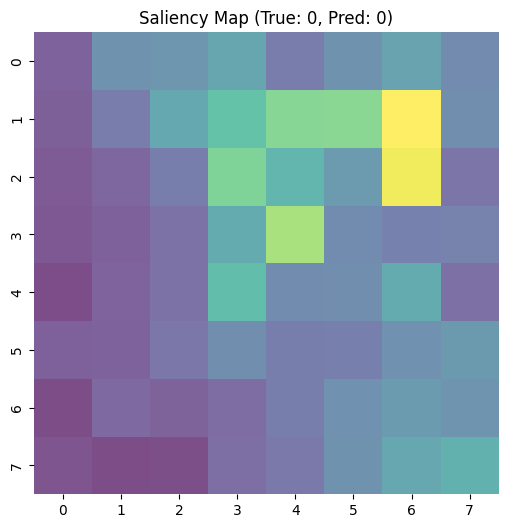

Actual Board Position:


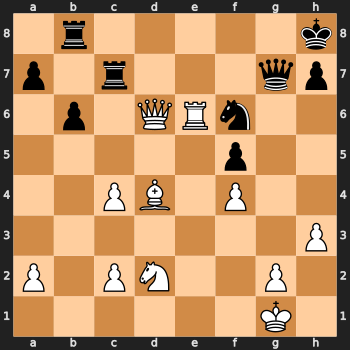

In [75]:
# ==========================================
# Saliency Maps
# ==========================================
if Config.TEST_MODE == "DATASET":
    # Load index from JSON
    index_path = RESULTS_DIR / ACTIVE_SETUP['name'] / ACTIVE_SETUP['index_file']
    with open(index_path, "r") as f:
        index_data = json.load(f)
    dataset_idx = index_data[Config.ERROR_MAGNITUDE][Config.IDX_IN_LIST]
    
    # Load sample
    dataset = ChessDataset(root_dir=ACTIVE_SETUP['dataset_dir'], split="test")
    X_sample, y_sample = dataset[dataset_idx]
    true_label = y_sample.item()
    
    # Generate FEN for printing
    reconstructed_fen = tensor_to_fen(X_sample) if ACTIVE_SETUP['is_3d'] else vector_to_fen(X_sample)
    print(f"\nMode: DATASET | Analyzing Test Sample Index: {dataset_idx}")

elif Config.TEST_MODE == "FEN":
    reconstructed_fen = Config.FEN_STRING
    true_label = Config.TRUE_LABEL_FOR_FEN
    raw_tensor = fen_to_tensor(reconstructed_fen) if ACTIVE_SETUP['is_3d'] else fen_to_vector(reconstructed_fen)
    X_sample = torch.tensor(raw_tensor, dtype=torch.float32)
    print(f"\nMode: FEN STRING")

X_input = X_sample.unsqueeze(0).to(DEVICE)
pred_logits = model(X_input)
pred_label = torch.argmax(pred_logits, dim=1).item()

grads = get_piece_gradients(model, X_input, pred_label)
if len(grads.shape) == 3: # Flatten spatial maps
    grads = grads.flatten()

print(f"FEN: {reconstructed_fen}")
print(f"True Label: {true_label} | Predicted: {pred_label}")
print(f"Error Magnitude: {abs(true_label - pred_label)}")

plot_chess_gradients(grads)
plot_chess_heatmap(grads, fen_str=reconstructed_fen, true_label=true_label, pred_label=pred_label)

In [76]:
# ==========================================
# Dataset Alignment Check
# ==========================================
CHECK_IDX = 1300
SPLIT = "test"

planes_dataset = ChessDataset(root_dir=Path("./dataset_planes_cp_probe/"), split=SPLIT)
bitmaps_dataset = ChessDataset(root_dir=Path("./dataset_bitmaps_cp_probe/"), split=SPLIT)

X_plane, y_plane = planes_dataset[CHECK_IDX]
X_bitmap, y_bitmap = bitmaps_dataset[CHECK_IDX]

fen_from_plane = tensor_to_fen(X_plane)
fen_from_bitmap = vector_to_fen(X_bitmap)

print(f"--- Checking Index {CHECK_IDX} ({SPLIT} split) ---")
print(f"Planes  Label: {y_plane.item()} | FEN: {fen_from_plane}")
print(f"Bitmaps Label: {y_bitmap.item()} | FEN: {fen_from_bitmap}")

if fen_from_plane == fen_from_bitmap and y_plane.item() == y_bitmap.item():
    print("\n✅ Match! Both datasets represent the exact same board and evaluation at this index.")
else:
    print("\n❌ Mismatch! The datasets do not align. You might need to check your data generation pipeline.")

--- Checking Index 1300 (test split) ---
Planes  Label: 0 | FEN: 3r2k1/6qp/2RQb3/4Ppp1/8/P3P1P1/5KNP/8 w - - 0 1
Bitmaps Label: 0 | FEN: 3r2k1/6qp/2RQb3/4Ppp1/8/P3P1P1/5KNP/8 w - - 0 1

✅ Match! Both datasets represent the exact same board and evaluation at this index.


In [ ]:
import chess
import chess.svg

def save_chess_board_svg(fen, save_name, size=350):
    """
    Generates an SVG image of a chess board from a FEN string and saves it.
    """
    if not save_name.endswith('.svg'):
        save_name += '.svg'

    board = chess.Board(fen)

    board_svg = chess.svg.board(board, size=size)
    with open(save_name, "w") as f:
        f.write(board_svg)
        
    print(f"Board successfully saved to {save_name}")

test_fen = "8/8/8/8/7k/1R2p3/4pp2/4K3 w - - 0 1"
save_chess_board_svg(test_fen, "index_1")

Board successfully saved to index_1.svg
